## Linking Mesoscale Convective System Tracks to Extreme Precipitation: A Satellite-Driven and Ensemble Modeling Analysis of the 2015 Texas Flood Event
##### Samkeyat Shohan*, Hsin-I Chang, CL. Castro, CB Risanto, Yoshimitsu Chikamoto, Patrick Bunn
We will describe the codes in the following steps:
1. Spatial Regridding
2. Brightness Temperature (TB) Calculation for WRF Files (NCL script)
3. WRF Tb: Creating MERGIR-like Files required for MCS Tracking Algorithm
4. Combining GPM Precip and MERGIR Tb data for the analysis
5. Kernel Density Estimation (KDE) of MCS Tracks and Heavy Precipitation
6. Plotting Precipitation Accumulation for GPM
7. Event-wise collocation Between MCS Tracks and Precipitation
8. Plotting Event-wise Collocation

#### 1. Spatial Regridding

In [ ]:
import xarray as xr
import numpy as np
from scipy.interpolate import RegularGridInterpolator
import glob, os

# ================= User Options =================
GRID_KM_LIST = [4.0]      # you can put [4.0, 8.0, 16.0] if desired
LON_CONV = "-180_180"     # or "0_360" for output longitude range

# Variables to regrid (must live on a regular lat-lon grid)
VARS_TO_REGRID = ["Tb"]   # change as needed, e.g. ["Tb", "precipitationCal"]

OUT_PREFIX = "regridded_{km}km_"

# ======== Filename label mapping (optional cosmetic) ========
_KM_LABEL_MAP = {4.0: 4, 8.0: 8, 16.0: 16}
_TOL = 1e-2

def km_to_label(km: float) -> int:
    """Map grid spacing to a nice label for filenames."""
    k_best = min(_KM_LABEL_MAP.keys(), key=lambda k: abs(k - km))
    if abs(k_best - km) <= _TOL:
        return _KM_LABEL_MAP[k_best]
    return int(round(km))

# ================ Helpers ==================
def normalize_lon(lon, to_range):
    lon = np.asarray(lon, dtype=float)
    if to_range == "0_360":
        # Convert -180..180 → 0..360
        return np.where(lon < 0, lon + 360.0, lon)
    # target is "-180_180"
    return ((lon + 180.0) % 360.0) - 180.0

def km_to_degree_steps(grid_km, mid_lat_deg):
    """
    Convert desired km spacing to degree steps at a given mid-latitude.
    """
    dlat = grid_km / 110.574
    c = np.cos(np.deg2rad(mid_lat_deg))
    dlon = dlat if c < 1e-8 else grid_km / (111.320 * c)
    return dlat, dlon

def find_lat_lon(ds: xr.Dataset):
    """
    Try to infer 1D latitude and longitude coordinate names + values
    from a dataset in a generic way.
    """
    lat_name = None
    lon_name = None

    # 1. Look for "axis" attribute
    for vname, v in ds.variables.items():
        if getattr(v, "axis", "").upper() == "Y":
            lat_name = vname
        if getattr(v, "axis", "").upper() == "X":
            lon_name = vname

    # 2. Fall back to common names if still missing
    if lat_name is None:
        for candidate in ["lat", "latitude", "y"]:
            if candidate in ds.variables and ds[candidate].ndim == 1:
                lat_name = candidate
                break

    if lon_name is None:
        for candidate in ["lon", "longitude", "x"]:
            if candidate in ds.variables and ds[candidate].ndim == 1:
                lon_name = candidate
                break

    if lat_name is None or lon_name is None:
        raise ValueError(
            "Could not infer lat/lon names. "
            "Check that the dataset has 1D lat/lon coordinate variables."
        )

    lat = np.asarray(ds[lat_name].values)
    lon = np.asarray(ds[lon_name].values)
    return lat_name, lon_name, lat, lon

def to_time_lat_lon(da: xr.DataArray, lat_dim: str, lon_dim: str):
    """
    Ensure the DataArray has dims (time, lat_dim, lon_dim) in that order.
    If there is no time dimension, create one with length 1.
    """
    dims = list(da.dims)

    # add a time dimension if missing
    if "time" not in dims:
        da = da.expand_dims("time")  # new time dim size=1
        dims = list(da.dims)

    # we now expect that lat_dim and lon_dim appear in dims
    if lat_dim not in dims or lon_dim not in dims:
        raise ValueError(
            f"Variable {da.name} does not have expected lat/lon dims "
            f"({lat_dim}, {lon_dim}); got {dims}"
        )

    # Transpose to (time, lat, lon)
    return da.transpose("time", lat_dim, lon_dim)

# ========== Files ==========
files = sorted(glob.glob("*.nc")) + sorted(glob.glob("*.nc4"))
if not files:
    raise SystemExit("No .nc or .nc4 files found in the current directory.")

# ========== Fixed 4-corner domain (EDIT IF NEEDED) ==========
# Works on any dataset *as long as* it covers this region.
TOP_LEFT      = (37.019757, -107.096605)
BOTTOM_LEFT   = (25.442889, -107.404222)
TOP_RIGHT     = (37.216874, -92.430630)
BOTTOM_RIGHT  = (25.189648, -91.990790)

all_lats = np.array([
    TOP_LEFT[0],
    BOTTOM_LEFT[0],
    TOP_RIGHT[0],
    BOTTOM_RIGHT[0],
])
all_lons = np.array([
    TOP_LEFT[1],
    BOTTOM_LEFT[1],
    TOP_RIGHT[1],
    BOTTOM_RIGHT[1],
])

lat_min = float(all_lats.min())
lat_max = float(all_lats.max())
lon_min = float(all_lons.min())
lon_max = float(all_lons.max())

mid_lat = 0.5 * (lat_min + lat_max)

# Precompute target grid(s)
target_grids = {}
for km in GRID_KM_LIST:
    dlat, dlon = km_to_degree_steps(km, mid_lat)
    pad_lat = 0.25 * dlat
    pad_lon = 0.25 * dlon

    lat_new = np.arange(lat_min - pad_lat, lat_max + pad_lat + 0.5 * dlat, dlat)
    lon_new = np.arange(lon_min - pad_lon, lon_max + pad_lon + 0.5 * dlon, dlon)

    lat2d, lon2d = np.meshgrid(lat_new, lon_new, indexing="ij")
    eval_points = np.column_stack([lat2d.ravel(), lon2d.ravel()])

    target_grids[km] = {
        "lat": lat_new,
        "lon": lon_new,
        "eval_points": eval_points,
        "dlat": dlat,
        "dlon": dlon,
    }

    print(f"[Grid {km:.2f} km → label {km_to_label(km)}]")
    print(f"  nlat={lat_new.size}, nlon={lon_new.size}")
    print(f"  dlat={dlat:.5f}°, dlon@{mid_lat:.1f}°={dlon:.5f}°")

print("\nFixed domain:")
print(f"  lat: {lat_min:.3f} .. {lat_max:.3f}")
print(f"  lon: {lon_min:.3f} .. {lon_max:.3f}")

# ================= Regridding =================
def regrid_file_to_grid(fp, vars_to_regrid, km):

    tg = target_grids[km]
    lat_new = tg["lat"]
    lon_new = tg["lon"]
    eval_points = tg["eval_points"]

    # Generic: avoid time decode issues
    with xr.open_dataset(fp, decode_times=False) as ds:

        # Infer lat/lon names + arrays
        lat_name, lon_name, lat_src, lon_src = find_lat_lon(ds)

        # Normalize longitudes to requested range
        lon_src = normalize_lon(lon_src, LON_CONV)

        # Check if lat/lon descending; if so, flip
        flip_lat = lat_src[0] > lat_src[-1]
        flip_lon = lon_src[0] > lon_src[-1]

        if flip_lat:
            lat_src = lat_src[::-1]
        if flip_lon:
            lon_src = lon_src[::-1]

        data_out = {}
        carried_attrs = {}
        ntime_out = None  # will be inferred from the first successfully processed variable

        for v in vars_to_regrid:
            if v not in ds:
                print(f"  ⚠ Skipping '{v}' — not in file")
                continue

            da = ds[v]
            # Ensure (time, lat, lon) in the correct order
            da = to_time_lat_lon(da, lat_dim=lat_name, lon_dim=lon_name)
            arr = np.asarray(da.values)

            # Determine time length consistently
            if ntime_out is None:
                ntime_out = arr.shape[0]
            else:
                if arr.shape[0] != ntime_out:
                    raise ValueError(
                        f"Variable {v} has ntime={arr.shape[0]}, "
                        f"expected {ntime_out}"
                    )

            # Apply flipping if needed
            if flip_lat:
                arr = arr[:, ::-1, :]
            if flip_lon:
                arr = arr[:, :, ::-1]

            # Prepare output array
            out = np.full(
                (ntime_out, lat_new.size, lon_new.size),
                np.nan,
                dtype=np.float32
            )

            # Interpolate each time slice
            for t in range(ntime_out):
                f = RegularGridInterpolator(
                    (lat_src, lon_src),
                    arr[t, :, :],
                    method="linear",
                    bounds_error=False,
                    fill_value=np.nan,
                )
                out[t] = f(eval_points).reshape(lat_new.size, lon_new.size)

            data_out[v] = (("time", "lat", "lon"), out)

            # Carry over useful attributes
            for k_attr in ["units", "long_name", "standard_name"]:
                if k_attr in da.attrs:
                    carried_attrs.setdefault(v, {})[k_attr] = da.attrs[k_attr]

        if not data_out:
            print(f"  No requested variables found in {fp}.")
            return

        # ---- Build time coordinate ----
        if "time" in ds.coords or "time" in ds.variables:
            raw_time = ds["time"].values
            time_vals = np.atleast_1d(raw_time)
            if time_vals.size != ntime_out:
                # fallback if mismatch
                time_vals = np.arange(ntime_out, dtype="float64")
        else:
            # dataset had no time; we created a dummy dim
            time_vals = np.arange(ntime_out, dtype="float64")

        label_km = km_to_label(km)

        ds_new = xr.Dataset(
            data_vars=data_out,
            coords={
                "time": ("time", time_vals),
                "lat": ("lat", lat_new),
                "lon": ("lon", lon_new),
            },
            attrs={
                "source_file": os.path.basename(fp),
                "regridding_method": "RegularGridInterpolator (linear)",
                "target_grid_km": float(km),
                "target_grid_label_km": int(label_km),
            },
        )

        # Reattach variable attributes
        for v, at in carried_attrs.items():
            for k_attr, val in at.items():
                ds_new[v].attrs[k_attr] = val

        # Encoding
        enc = {
            vn: {
                "_FillValue": np.float32(np.nan),
                "zlib": True,
                "complevel": 4,
                "dtype": "float32",
            }
            for vn in data_out.keys()
        }

        outname = OUT_PREFIX.format(km=label_km) + os.path.basename(fp)
        ds_new.to_netcdf(outname, encoding=enc)
        print(f"  ✅ Saved {outname}")

# ================= Run =================
for fp in files:
    print(f"\nRegridding {os.path.basename(fp)}:")
    for km in GRID_KM_LIST:
        regrid_file_to_grid(fp, VARS_TO_REGRID, km)

#### 2. Brightness Temperature (TB) Calculation for WRF Files (NCL script)

In [ ]:
;=============================================================
; split_Tb_hourly_named_like_wrfout.ncl
; Output: wrfout_d02_YYYY-MM-DD_HH.nc
;=============================================================
begin
  inFile    = "wrfout_d02_2015-05-20_00_24h.nc"
  targetVar = "Tb"

  f = addfile(inFile, "r")

  if (.not. isfilevar(f, targetVar)) then
    print("FATAL: variable '" + targetVar + "' not found in " + inFile)
    print("Available variables:")
    print(getfilevarnames(f))
    exit
  end if

  Tb_all   = f->$targetVar$
  dimNames = getvardims(Tb_all)
  tDim     = dimNames(0)
  yDim     = dimNames(1)
  xDim     = dimNames(2)

  nt = dimsizes(Tb_all(:,0,0))
  ny = dimsizes(Tb_all(0,:,0))
  nx = dimsizes(Tb_all(0,0,:))

  hasTimeStr = isfilevar(f, "time")   ; char time(Time, DateStrLen)
  hasLat     = isfilevar(f, "lat")
  hasLon     = isfilevar(f, "lon")

  if (hasTimeStr) then
    time_char = f->time
    ; Example string: "2015-05-20_00:00:00"
    base_date = str_get_cols(chartostring(time_char(0,:)), 0, 9)  ; "2015-05-20"
  else
    ; Fallback: hard-code or parse from filename
    base_date = "2015-05-20"
  end if

  do hour = 0, nt-1
    hh      = sprinti("%02i", hour)
    outFile = "wrfout_d02_" + base_date + "_" + hh + ".nc"
    w       = addfile(outFile, "c")

    ; Dimensions: time=1 for Tb
    filedimdef(w, tDim, 1, False)
    filedimdef(w, yDim, ny, False)
    filedimdef(w, xDim, nx, False)

    ; Tb
    filevardef(w, targetVar, typeof(Tb_all), (/tDim, yDim, xDim/))
    filevarattdef(w, targetVar, Tb_all)

    ; lat/lon as 2D per file (y,x)
    if (hasLat) then
      filevardef(w, "lat", typeof(f->lat), (/yDim, xDim/))
      filevarattdef(w, "lat", f->lat)
    end if
    if (hasLon) then
      filevardef(w, "lon", typeof(f->lon), (/yDim, xDim/))
      filevarattdef(w, "lon", f->lon)
    end if

    ; Write data
    w->$targetVar$(0,:,:) = Tb_all(hour,:,:)
    if (hasLat) then
      w->lat(:,:) = f->lat(hour,:,:)
    end if
    if (hasLon) then
      w->lon(:,:) = f->lon(hour,:,:)
    end if

    ; Save the exact timestamp as a global attribute
    if (hasTimeStr) then
      w@time_string = chartostring(time_char(hour,:))
    else
      w@time_string = base_date + "_" + hh
    end if

    print("Wrote: " + outFile + "   time_string=" + w@time_string)
  end do

end

#### 3. WRF Tb: Creating MERGIR-like Files required for MCS Tracking Algorithm

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import netCDF4 as nc


def hourly_infile(date_str, hour):
    return f"wrfout_d02_{date_str}_{hour:02d}.nc"


def hourly_outfile(date_str, hour):
    yyyymmdd = date_str.replace("-", "")
    return f"merg_{yyyymmdd}{hour:02d}_4km-pixel.nc4"


def convert_all_hours(
    date_str="2015-05-20",
    tb_var="Tb",
    lat_var="lat",
    lon_var="lon",
    fill_bad_threshold=-400.0,
    fill_value=329.0,
):
    """
    Convert 24 hourly wrfout_d02 files into 24 MERG-style files.

    Input : wrfout_d02_YYYY-MM-DD_HH.nc
    Output: merg_YYYYMMDDHH_4km-pixel.nc4
    """

    for hour in range(24):
        in_file = Path(hourly_infile(date_str, hour))
        out_file = Path(hourly_outfile(date_str, hour))

        if not in_file.exists():
            raise FileNotFoundError(f"Missing input file: {in_file}")

        with nc.Dataset(in_file) as src:
            # --- Read variables ---
            Tb = src.variables[tb_var][:].astype(np.float32)   # (1,y,x)
            Tb = Tb[0, :, :]                                   # -> (y,x)
            Tb = np.where(Tb < fill_bad_threshold, fill_value, Tb)

            lat = src.variables[lat_var][:].astype(np.float32)
            lon = src.variables[lon_var][:].astype(np.float32)

            time_string = getattr(
                src, "time_string", f"{date_str}_{hour:02d}:00:00"
            )

            ny, nx = Tb.shape

        # --- Write output file ---
        with nc.Dataset(out_file, "w", format="NETCDF4_CLASSIC") as out:
            # Dimensions
            out.createDimension("time", 1)
            out.createDimension("y", ny)
            out.createDimension("x", nx)
            out.createDimension("DateStrLen", 19)

            # Variables
            vtime = out.createVariable("time", "f8", ("time",))
            vlat  = out.createVariable("lat", "f4", ("y", "x"))
            vlon  = out.createVariable("lon", "f4", ("y", "x"))
            vtb   = out.createVariable("Tb",  "f4", ("time", "y", "x"), zlib=True)
            vts   = out.createVariable("time_string", "S1", ("time", "DateStrLen"))

            # Attributes
            vtime.units = f"days since {date_str} {hour:02d}:00:00"
            vtime.calendar = "gregorian"

            vlat.units = "degree_north"
            vlon.units = "degree_east"

            vtb.units = "K"
            vtb.standard_name = "brightness temperature"
            vtb.coordinates = "time lat lon"

            out.description = "Hourly Tb converted from wrfout_d02 file."

            # Write data
            vtime[:] = 0.0
            vlat[:, :] = lat
            vlon[:, :] = lon
            vtb[0, :, :] = Tb

            # Write time_string
            ts = time_string[:19].ljust(19)
            vts[0, :] = np.array(list(ts.encode("ascii")), dtype="S1")

        print(f"Wrote: {out_file}")


if __name__ == "__main__":
    convert_all_hours(date_str="2015-05-20")

#### 4. Combining GPM Precip and MERGIR Tb data for the analysis

In [ ]:
import glob
import netCDF4 as nc
import numpy as np
import re
import os

# ----------------------------------------
# Helper to extract timestamp from filename
# ----------------------------------------
def extract_timestamp(filepath):
    """
    Extract YYYYMMDDHH from filenames such as:
    - 3B-HHR.MS.MRG.3IMERG.20150521-S000000-E002959...
    - merg_2015052100_4km-pixel.nc4.nc4
    """
    filename = os.path.basename(filepath)

    # Pattern A: 3B-HHR ..... 20150521-S010000
    m = re.search(r'(\d{8})-S(\d{2})', filename)
    if m:
        date = m.group(1)
        hour = m.group(2)
        return f"{date}{hour}"

    # Pattern B: merg_2015052100_4km-pixel.nc4.nc4
    m = re.search(r'(\d{10})', filename)
    if m:
        return m.group(1)

    raise ValueError(f"Cannot extract timestamp from {filename}")

# ----------------------------------------
# File patterns
# ----------------------------------------
gpm_files = sorted(glob.glob("regridded_4km_3B*.nc"))
merg_files = sorted(glob.glob("regridded_4km_merg*.nc4.nc4"))

if len(gpm_files) != len(merg_files):
    print(f"⚠ WARNING: file count mismatch — GPM={len(gpm_files)}, MERG={len(merg_files)}")

# ----------------------------------------
# Processing Loop
# ----------------------------------------
for i in range(min(len(gpm_files), len(merg_files))):

    gpm_fp  = gpm_files[i]
    merg_fp = merg_files[i]

    print(f"\nProcessing pair {i+1}:")
    print(f"  GPM  : {gpm_fp}")
    print(f"  MERG : {merg_fp}")

    # ---- Extract timestamp ----
    timestamp = extract_timestamp(gpm_fp)  # safer: GPM always has timestamp
    outname = f"regridded_4km_GPM_Precip_MERGIR_Tb_{timestamp}.nc"

    # ---- Read MERG Tb ----
    with nc.Dataset(merg_fp, 'r') as msrc:
        if "Tb" not in msrc.variables:
            print("  ⚠ MERG file has no Tb variable — skipping")
            continue

        tb_src = msrc.variables["Tb"]
        tb_data = tb_src[:]            # (time, lat, lon)
        tb_dtype = tb_src.datatype
        tb_fill  = getattr(tb_src, "_FillValue", np.nan)

    # ---- Read GPM (3B) and write new file with Tb inserted ----
    with nc.Dataset(gpm_fp, "r") as src:
        with nc.Dataset(outname, "w") as dst:

            # Global attributes
            dst.setncatts(src.__dict__)

            # Dimensions
            for name, dim in src.dimensions.items():
                dst.createDimension(name,
                    len(dim) if not dim.isunlimited() else None
                )

            # Copy all variables except OLD Tb
            for name, var in src.variables.items():
                if name == "Tb":
                    continue

                new_var = dst.createVariable(
                    name, var.datatype, var.dimensions,
                    fill_value=getattr(var, "_FillValue", None)
                )
                new_var.setncatts({
                    k:v for k,v in var.__dict__.items()
                    if k != "_FillValue"
                })
                new_var[:] = var[:]

            # ---- Insert NEW Tb (time, lat, lon) ----
            time_len = len(dst.dimensions["time"])
            lat_len  = len(dst.dimensions["lat"])
            lon_len  = len(dst.dimensions["lon"])

            if tb_data.shape != (time_len, lat_len, lon_len):
                raise RuntimeError(
                    f"MERG Tb shape {tb_data.shape} does not match "
                    f"GPM dims (time={time_len}, lat={lat_len}, lon={lon_len})"
                )

            tb_var = dst.createVariable(
                "Tb", tb_dtype, ("time", "lat", "lon"),
                fill_value=tb_fill
            )

            # Copy MERG Tb attributes
            for attr in tb_src.ncattrs():
                if attr != "_FillValue":
                    setattr(tb_var, attr, getattr(tb_src, attr))

            tb_var[:] = tb_data

    print(f"  ✅ Saved: {outname}")

print("\nAll processing complete.")

#### 5. Kernel Density Estimation (KDE) of MCS Tracks and Heavy Precipitation

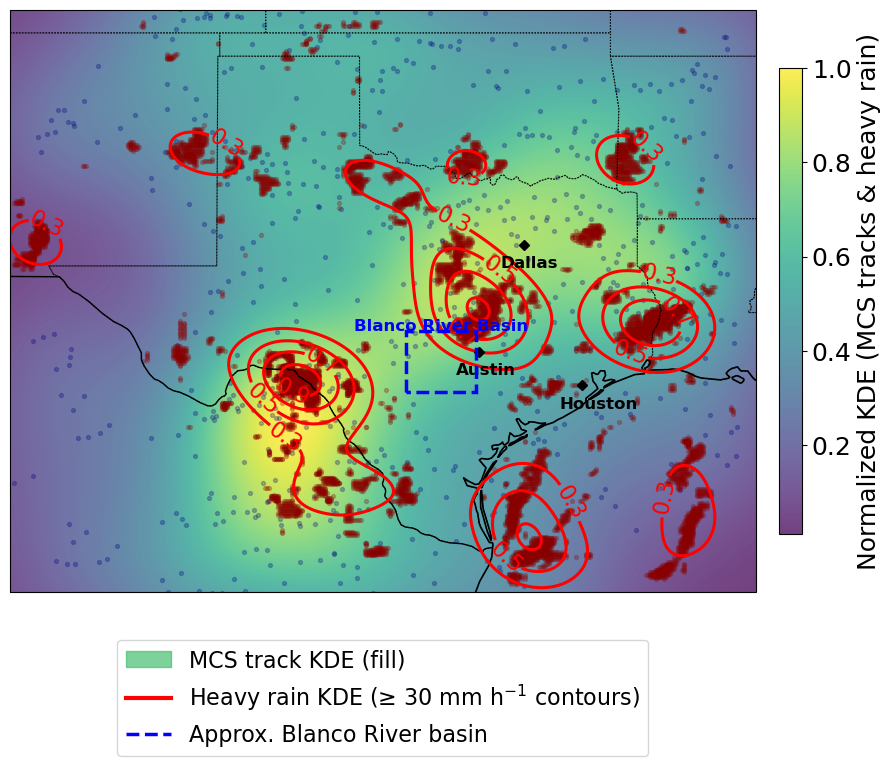

Saved combined KDE map to: viridis_MCS_core_vs_heavy_rain_KDE.png


In [3]:
"""
Combined KDE map:
- Cold-core MCS track density (from MERGIR_stats_tracknumbersv4.4_20150520_20150530.nc)
- Heavy precipitation KDE (from regridded_4km_GPM_Precip_MERGIR_Tb_*.nc)

Cold cores: filled KDE shading
Heavy precip: KDE contours
Threshold: precipitation >= 30 mm/h
"""

import warnings
warnings.filterwarnings("ignore")

import glob
import numpy as np
from netCDF4 import Dataset
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

# ---------------- USER SETTINGS ----------------
FILE_STATS  = "MERGIR_stats_tracknumbersv4.4_20150520_20150530.nc"
PRECIP_GLOB = "regridded_4km_GPM_Precip_MERGIR_Tb_*.nc"
OUT_PNG     = "viridis_MCS_core_vs_heavy_rain_KDE.png"

MAP_EXTENT   = [-107.5, -91.5, 25.0, 37.5]
NX, NY       = 800, 800
PRECIP_THRESH = 30.0  # mm/h

# ---------------- FONT SIZE SETTINGS ----------------
FS_TITLE  = 22
FS_LABEL  = 20
FS_TICK   = 18
FS_CB     = 18
FS_CLABEL = 16
FS_LEGEND = 16

plt.rcParams.update({
    "font.size": FS_TICK,
    "axes.labelsize": FS_LABEL,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_LEGEND
})

# ---------------- 1. LOAD COLD-CORE TRACK STATS ----------------
nc = Dataset(FILE_STATS, "r")
meanlatcore = nc.variables["meanlatcore"][:]
meanloncore = nc.variables["meanloncore"][:]
nc.close()

valid_core = np.isfinite(meanlatcore) & np.isfinite(meanloncore)
lat_core = meanlatcore[valid_core]
lon_core = meanloncore[valid_core]

# ---------------- 2. GATHER HEAVY PRECIP (>= PRECIP_THRESH mm/h) ----------------
precip_files = sorted(glob.glob(PRECIP_GLOB))
lat_1d = None
lon_1d = None
heavy_lat_list = []
heavy_lon_list = []

for f in precip_files:
    ds_p = Dataset(f, "r")
    if lat_1d is None:
        lat_1d = ds_p.variables["lat"][:]
        lon_1d = ds_p.variables["lon"][:]

    precip = ds_p.variables["precipitationCal"][:]  # (time, lat, lon)
    ds_p.close()

    mask = (precip >= PRECIP_THRESH) & np.isfinite(precip)
    if np.any(mask):
        t_idx, iy, ix = np.where(mask)
        heavy_lat_list.append(lat_1d[iy])
        heavy_lon_list.append(lon_1d[ix])

if len(heavy_lat_list) == 0:
    raise RuntimeError("No grid points found with precip >= threshold.")

lat_rain = np.concatenate(heavy_lat_list)
lon_rain = np.concatenate(heavy_lon_list)

# ---------------- 3. KDE GRID ----------------
lon_min, lon_max, lat_min, lat_max = MAP_EXTENT
lon_grid = np.linspace(lon_min, lon_max, NX)
lat_grid = np.linspace(lat_min, lat_max, NY)
LON, LAT = np.meshgrid(lon_grid, lat_grid)
coords_grid = np.vstack([LON.ravel(), LAT.ravel()])

# ---------------- 4. KDE FOR COLD CORES ----------------
xy_core = np.vstack([lon_core, lat_core])
kde_core = gaussian_kde(xy_core)
core_norm = kde_core(coords_grid).reshape(LON.shape)
core_norm /= core_norm.max()

# ---------------- 5. KDE FOR HEAVY PRECIP ----------------
xy_rain = np.vstack([lon_rain, lat_rain])
kde_rain = gaussian_kde(xy_rain)
rain_norm = kde_rain(coords_grid).reshape(LON.shape)
rain_norm /= rain_norm.max()

# ---------------- 6. PLOT ----------------
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=proj)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

# Map features
ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=1.2)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=1.0)
ax.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.8, linestyle=":")

# Shading — MCS KDE
pcm = ax.pcolormesh(
    lon_grid, lat_grid, core_norm,
    cmap="viridis",
    alpha=0.75,
    shading="auto",
    transform=proj,
)

# Contours — Heavy rain KDE
levels = [0.3, 0.5, 0.7, 0.9]
cs = ax.contour(
    lon_grid, lat_grid, rain_norm,
    levels=levels,
    colors="red",
    linewidths=2.2,
    transform=proj,
)
ax.clabel(cs, inline=True, fontsize=FS_CLABEL, fmt="%.1f")

# Scatter points: MCS cores & heavy-rain grid points
ax.scatter(lon_core, lat_core, s=8, color="navy", alpha=0.25, transform=proj)
ax.scatter(lon_rain, lat_rain, s=8, color="darkred", alpha=0.25, transform=proj)

# ---------------- Add Major Texas Cities ----------------
cities = {
    'Dallas':  (-96.48, 32.46),
    'Houston': (-95.22, 29.45),
    'Austin':  (-97.44, 30.16),
}

for city, (clon, clat) in cities.items():
    ax.plot(clon, clat, 'kD', markersize=5, transform=proj)
    ax.text(
        clon - 0.5, clat - 0.5, city,
        transform=proj,
        fontsize=12,
        color='k',
        fontweight='bold'
    )

# ---------------- Add Approximate Blanco River Basin ----------------
# Rough box between Austin and San Antonio area
blanco_basin_coords = [
    (-99.0, 29.3),
    (-99.0, 30.6),
    (-97.5, 30.6),
    (-97.5, 29.3),
]

blanco_basin_patch = mpatches.Polygon(
    blanco_basin_coords,
    closed=True,
    edgecolor='blue',
    linewidth=2.5,
    linestyle='--',
    facecolor='none',
    transform=proj,
    zorder=5,
)
ax.add_patch(blanco_basin_patch)

# Label for basin
ax.text(
    -98.25, 30.55, "Blanco River Basin",
    transform=proj,
    fontsize=12,
    color='blue',
    ha='center',
    va='bottom',
    fontweight='bold',
    zorder=4,
)

# Colorbar
cbar = plt.colorbar(pcm, ax=ax, pad=0.02, shrink=0.8)
cbar.ax.tick_params(labelsize=FS_CB)
cbar.set_label("Normalized KDE (MCS tracks & heavy rain)", fontsize=FS_CB)

# ---------------- LEGEND AT BOTTOM ----------------
core_patch = mpatches.Patch(
    color=plt.cm.viridis(0.7),
    alpha=0.7,
    label="MCS track KDE (fill)"
)
rain_line = Line2D(
    [0], [0],
    color="red",
    lw=3,
    label=f"Heavy rain KDE (≥ {PRECIP_THRESH:.0f} mm h$^{{-1}}$ contours)"
)
basin_line = Line2D(
    [0], [0],
    color="blue",
    lw=2.5,
    linestyle='--',
    label="Approx. Blanco River basin"
)

ax.legend(
    handles=[core_patch, rain_line, basin_line],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=1,
    frameon=True
)

# Labels only (NO TITLE)
ax.set_xlabel("Longitude", fontsize=FS_LABEL)
ax.set_ylabel("Latitude", fontsize=FS_LABEL)

plt.tight_layout()
plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved combined KDE map to: {OUT_PNG}")

#### 6. Plotting Precipitation Accumulation for GPM

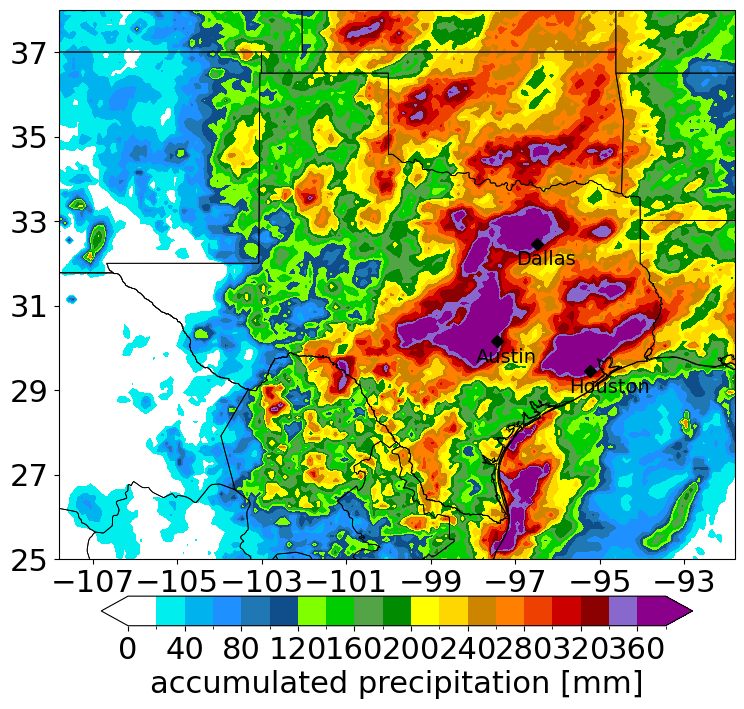

Saved: GPM_accumulated_precip_20150521_31.jpg


In [9]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1 import make_axes_locatable
from netCDF4 import Dataset

# ------------------------- USER SETTINGS -------------------------
NCFILE   = "GPM_accumulated_precip_20150521_31.nc"
OUTFIG   = "GPM_accumulated_precip_20150521_31.jpg"

EXTENT   = [-107.8, -91.8, 25, 38]  # [lon_min, lon_max, lat_min, lat_max]
XTICKS   = np.arange(-107, -91, 2)
YTICKS   = np.arange(25, 39, 2)

CITIES = {
    "Dallas":  (-96.48, 32.46),
    "Houston": (-95.22, 29.45),
    "Austin":  (-97.44, 30.16),
}

LEVELS = [0, 20, 40, 60, 80, 100, 120, 140, 160, 180,
          200, 220, 240, 260, 280, 300, 320, 340, 360, 380]

COLORS = [
    "white", "#00EEEE", "#00B2EE", "#1E90FF", "#1f77b4", "#104E8B", "#7FFF00",
    "#00CD00", "#53a447", "#008B00", "#FFFF00", "#FFD700", "#CD8500", "#FF7F00",
    "#EE4000", "#CD0000", "#8B0000", "#8968CD", "#912CEE", "#8B008B"
]

# ------------------------- HELPERS -------------------------
def read_gpm(nc_path: str):
    """Read lat/lon and precipitation from the NetCDF file."""
    with Dataset(nc_path, "r") as ds:
        lat = ds.variables["lat"][:]
        lon = ds.variables["lon"][:]
        precip = ds.variables["precipitationCal"][:, :]
    return lon, lat, precip

def make_cmap_and_norm(levels, colors):
    cmap = mcolors.ListedColormap(colors)
    # Discrete normalization that matches your explicit LEVELS
    norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, clip=False)
    return cmap, norm

def plot_precip(lon, lat, precip, outfig: str):
    plt.rcParams.update({"font.size": 22})

    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent(EXTENT, crs=ccrs.PlateCarree())

    # Map features
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.8, edgecolor="k")
    ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor="k")
    ax.add_feature(cfeature.STATES, linewidth=0.6, edgecolor="k")

    # Gridlines (hidden labels/lines to match your original)
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                      linewidth=1, color="black", alpha=0.5, linestyle="--")
    gl.xlines = False
    gl.ylines = False

    # City markers
    for name, (x, y) in CITIES.items():
        ax.plot(x, y, "kD", transform=ccrs.PlateCarree())
        ax.text(x - 0.5, y - 0.5, name, transform=ccrs.PlateCarree(),
                fontsize=14, color="k")

    # Ticks
    ax.set_xticks(XTICKS, crs=ccrs.PlateCarree())
    ax.set_yticks(YTICKS, crs=ccrs.PlateCarree())
    ax.tick_params(axis="both", which="major", labelsize=22)

    # Plot
    cmap, norm = make_cmap_and_norm(LEVELS, COLORS)
    pc = ax.contourf(lon, lat, precip,
                     levels=LEVELS, cmap=cmap, norm=norm,
                     extend="both", transform=ccrs.PlateCarree())

    # Colorbar
    cbar = fig.colorbar(pc, orientation="horizontal", fraction=0.048, pad=0.06, extend="both")
    cbar.set_label("accumulated precipitation [mm]", fontsize=22)
    cbar.ax.tick_params(labelsize=22)

    # Save
    outfig = str(Path(outfig))
    fig.savefig(outfig, dpi=360, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: {outfig}")

# ------------------------- MAIN -------------------------
if __name__ == "__main__":
    lon, lat, precip = read_gpm(NCFILE)
    plot_precip(lon, lat, precip, OUTFIG)

#### 7. Event-wise Collocation Between MCS Tracks and Precipitation

In [4]:
import os
import math
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
from netCDF4 import Dataset, num2date

# ================== USER SETTINGS ==================

STATS_FILE = "MERGIR_stats_tracknumbersv4.4_20150520_20150530.nc"
MCS_FILE   = "MERGIR_mcs_tracks_20150520_20150530.nc"

# Pattern for hourly precip/Tb files:
# e.g., regridded_4km_GPM_Precip_MERGIR_Tb_2015052109.nc
PRECIP_PREFIX = "regridded_4km_GPM_Precip_MERGIR_Tb_"
PRECIP_SUFFIX = ".nc"

RADIUS_KM = 100.0
OUT_CSV   = "MCS_tracks_with_precip_100km_from_core.csv"

ROUND_TO_NEAREST_HOUR = True
EARTH_RADIUS_KM       = 6371.0

# ===================================================

def round_datetime_to_nearest_hour(dt: datetime) -> datetime:
    if not ROUND_TO_NEAREST_HOUR:
        return dt.replace(minute=0, second=0, microsecond=0)
    if dt.minute >= 30:
        dt = dt + timedelta(hours=1)
    return dt.replace(minute=0, second=0, microsecond=0)


def decode_datetimestring_char_array(charr) -> np.ndarray:
    """
    Decode a 3D char array [ntracks, ntimes, strlen] into
    an array of np.datetime64[ns], with NaT where masked/empty.

    This version mimics your original code's behavior:
    - decodes bytes
    - strips nulls and whitespace
    - tries '%Y-%m-%d_%H:%M'
    - tries '%Y-%m-%d_%H:%M:%S'
    - and, if needed, both on s[:-1]
    """
    ntracks, ntimes, strlen = charr.shape
    out = np.full((ntracks, ntimes), np.datetime64("NaT"), dtype="datetime64[ns]")

    n_valid = 0

    for i in range(ntracks):
        for j in range(ntimes):
            if np.ma.is_masked(charr[i, j, :]):
                continue

            # Raw decode
            s = charr[i, j, :].tobytes().decode("utf-8")
            # Remove null chars and whitespace
            s = s.replace("\x00", "").strip()
            if not s:
                continue

            dt_parsed = None

            # Try without seconds first (like your original)
            for fmt in ("%Y-%m-%d_%H:%M", "%Y-%m-%d_%H:%M:%S"):
                try:
                    dt_parsed = datetime.strptime(s, fmt)
                    break
                except ValueError:
                    pass

            # If still failing, try your original "[:-1]" trick
            if dt_parsed is None and len(s) > 1:
                s2 = s[:-1]
                for fmt in ("%Y-%m-%d_%H:%M", "%Y-%m-%d_%H:%M:%S"):
                    try:
                        dt_parsed = datetime.strptime(s2, fmt)
                        break
                    except ValueError:
                        pass

            if dt_parsed is not None:
                out[i, j] = np.datetime64(dt_parsed)
                n_valid += 1
            # else: leave as NaT

    print(f"Decoded {n_valid} valid datetimes out of {ntracks * ntimes}")
    return out


def haversine_distance_km(lat_c, lon_c, lat2d, lon2d):
    lat1 = np.radians(lat_c)
    lon1 = np.radians(lon_c)
    lat2 = np.radians(lat2d)
    lon2 = np.radians(lon2d)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2.0 * np.arcsin(np.sqrt(a))
    return EARTH_RADIUS_KM * c


def get_precip_stats_for_centroid(lat_c, lon_c, dt_rounded, precip_cache):
    """
    Robustly get mean/max precip within RADIUS_KM around (lat_c, lon_c).

    - Tries to use time_var.units (or time_var.Units) with num2date.
    - If no time units exist or num2date fails, defaults to using
      the first time slice (t_idx = 0).
    """
    ymdh = dt_rounded.strftime("%Y%m%d%H")
    fname = os.path.join(f"{PRECIP_PREFIX}{ymdh}{PRECIP_SUFFIX}")

    if not os.path.exists(fname):
        return np.nan, np.nan, fname, None

    if fname not in precip_cache:
        ds = Dataset(fname, "r")
        lat = ds.variables["lat"][:]
        lon = ds.variables["lon"][:]
        time_var = ds.variables["time"]

        # Try to get time units robustly
        units_attr = None
        if hasattr(time_var, "units"):
            try:
                units_attr = time_var.units
            except Exception:
                units_attr = None
        if units_attr is None and hasattr(time_var, "Units"):
            try:
                units_attr = time_var.Units
            except Exception:
                units_attr = None

        if units_attr is not None:
            try:
                time_datetimes = num2date(time_var[:], units=units_attr)
                time_datetimes = np.array(time_datetimes, dtype="object")
            except Exception:
                time_datetimes = None
        else:
            time_datetimes = None

        precip_cache[fname] = {
            "ds": ds,
            "lat": lat,
            "lon": lon,
            "time_datetimes": time_datetimes,
        }
    else:
        cache = precip_cache[fname]
        ds = cache["ds"]
        lat = cache["lat"]
        lon = cache["lon"]
        time_datetimes = cache["time_datetimes"]

    # ----- Choose time index -----
    if time_datetimes is None:
        # No valid time metadata; just take the first time slice
        t_idx = 0
    else:
        target = np.datetime64(dt_rounded)
        times64 = np.array(time_datetimes, dtype="datetime64[ns]")
        dt_diffs = np.abs(times64 - target)
        t_idx = int(np.argmin(dt_diffs))

    precip = np.array(ds.variables["precipitationCal"][t_idx, :, :], dtype=float)

    # Approximate lat/lon window in degrees
    lat_window = RADIUS_KM / 111.0
    lat_c_rad = math.radians(lat_c)
    cos_lat = max(math.cos(lat_c_rad), 1e-6)
    lon_window = RADIUS_KM / (111.0 * cos_lat)

    lat_inds = np.where((lat >= lat_c - lat_window) & (lat <= lat_c + lat_window))[0]
    lon_inds = np.where((lon >= lon_c - lon_window) & (lon <= lon_c + lon_window))[0]

    if lat_inds.size == 0 or lon_inds.size == 0:
        return np.nan, np.nan, fname, t_idx

    lat_sub = lat[lat_inds]
    lon_sub = lon[lon_inds]
    lat2d, lon2d = np.meshgrid(lat_sub, lon_sub, indexing="ij")

    dist_km = haversine_distance_km(lat_c, lon_c, lat2d, lon2d)
    mask_circle = dist_km <= RADIUS_KM
    if not np.any(mask_circle):
        return np.nan, np.nan, fname, t_idx

    precip_sub = precip[np.ix_(lat_inds, lon_inds)]
    valid = np.isfinite(precip_sub) & mask_circle

    if not np.any(valid):
        return np.nan, np.nan, fname, t_idx

    mean_precip = float(np.mean(precip_sub[valid]))
    max_precip  = float(np.max(precip_sub[valid]))

    return mean_precip, max_precip, fname, t_idx


def build_core_from_stats_like_hint():
    """
    Use a robust matching:

    For each MCS track j:
      - find its first valid time (mcs_time[j, j0])
      - compute sum of its cloudnumber
      - search all stats tracks i:
          find first valid stats_time[i, i0]
          require same time AND same sum of cloudnumber
      - if found, copy stats meanlatcore/meanloncore/meantb to that MCS track.
    """
    # ---------- Open stats file ----------
    ds_stats = Dataset(STATS_FILE, "r")
    stats_lats = ds_stats.variables["meanlatcore"][:, :]
    stats_lons = ds_stats.variables["meanloncore"][:, :]
    stats_Tb   = ds_stats.variables["meantb"][:, :]
    stats_cloudnum = ds_stats.variables["cloudnumber"][:, :]
    stats_times_char = ds_stats.variables["datetimestring"][:]
    stats_time = decode_datetimestring_char_array(stats_times_char)

    ntracks_s, nmaxlength_s = stats_lats.shape

    # ---------- Open MCS file ----------
    ds_mcs = Dataset(MCS_FILE, "r")
    mcs_lats = ds_mcs.variables["meanlat"][:, :]
    mcs_lons = ds_mcs.variables["meanlon"][:, :]
    mcs_cloudnum = ds_mcs.variables["cloudnumber"][:, :]
    mcs_times_char = ds_mcs.variables["datetimestring"][:]
    mcs_time = decode_datetimestring_char_array(mcs_times_char)
    mcs_status = ds_mcs.variables["mcs_status"][:, :]
    base_time_mcs = ds_mcs.variables["base_time"][:, :]

    ntracks_m, ntimes = mcs_lats.shape

    print("Stats tracks:", ntracks_s, "MCS tracks:", ntracks_m)

    # ---------- Prepare arrays to hold core info on MCS grid ----------
    core_lats = np.full((ntracks_m, ntimes), np.nan, dtype=float)
    core_lons = np.full((ntracks_m, ntimes), np.nan, dtype=float)
    core_Tb   = np.full((ntracks_m, ntimes), np.nan, dtype=float)

    matched_count = 0

    for j in range(ntracks_m):
        # first valid time index for this MCS track
        valid_j = np.where(mcs_time[j, :] != np.datetime64("NaT"))[0]
        if valid_j.size == 0:
            print(f"MCS track {j}: no valid times")
            continue

        j0 = valid_j[0]
        t0 = mcs_time[j, j0]
        cn_mcs_sum = np.sum(mcs_cloudnum[j, :])

        found_i = -1
        for i in range(ntracks_s):
            valid_i = np.where(stats_time[i, :] != np.datetime64("NaT"))[0]
            if valid_i.size == 0:
                continue

            i0 = valid_i[0]
            t0_stats = stats_time[i, i0]
            if t0_stats != t0:
                continue

            cn_stats_sum = np.sum(stats_cloudnum[i, :])
            if cn_stats_sum == cn_mcs_sum:
                found_i = i
                break

        if found_i == -1:
            print(f"Warning: no matching STATS track found for MCS track {j} "
                  f"(t0={t0}, sum_cloudnum={cn_mcs_sum})")
            continue

        ncopy = min(ntimes, nmaxlength_s)
        core_lats[j, :ncopy] = stats_lats[found_i, :ncopy]
        core_lons[j, :ncopy] = stats_lons[found_i, :ncopy]
        core_Tb[j,   :ncopy] = stats_Tb[found_i,   :ncopy]

        print(f"MCS track {j} matched to STATS track {found_i} "
              f"(t0={t0}, sum_cloudnum={cn_mcs_sum})")

        matched_count += 1

    print(f"Filled core coordinates for {matched_count} MCS tracks "
          f"out of {ntracks_m}")

    return (
        ds_stats,
        ds_mcs,
        core_lats,
        core_lons,
        core_Tb,
        mcs_time,
        mcs_status,
        base_time_mcs,
        mcs_lats,
        mcs_lons,
    )


def main():
    (
        ds_stats,
        ds_mcs,
        core_lats,
        core_lons,
        core_Tb,
        mcs_time,
        mcs_status,
        base_time_mcs,
        meanlat_mcs,
        meanlon_mcs,
    ) = build_core_from_stats_like_hint()

    ntracks_m, ntimes = core_lats.shape
    rows = []
    precip_cache = {}

    for j in range(ntracks_m):
        for t in range(ntimes):
            status = mcs_status[j, t]
            if not np.isfinite(status) or status <= 0:
                continue  # skip non-MCS times

            bt = base_time_mcs[j, t]
            if bt == -999:
                continue

            try:
                dt = datetime.utcfromtimestamp(float(bt))
            except Exception:
                continue

            dt_rounded = round_datetime_to_nearest_hour(dt)

            # Choose centroid: core if available, else whole-MCS mean
            lat_c = core_lats[j, t]
            lon_c = core_lons[j, t]
            if not (np.isfinite(lat_c) and np.isfinite(lon_c)):
                lat_c = meanlat_mcs[j, t]
                lon_c = meanlon_mcs[j, t]
                if not (np.isfinite(lat_c) and np.isfinite(lon_c)):
                    continue

            mean_p, max_p, fname, t_idx = get_precip_stats_for_centroid(
                float(lat_c), float(lon_c), dt_rounded, precip_cache
            )

            rows.append(
                {
                    "mcs_track_id": j,
                    "time_index": t,
                    "datetime_utc": dt,
                    "datetime_hour_rounded": dt_rounded,
                    "mcs_status": float(status),
                    "meanlat_mcs": float(meanlat_mcs[j, t])
                    if np.isfinite(meanlat_mcs[j, t])
                    else np.nan,
                    "meanlon_mcs": float(meanlon_mcs[j, t])
                    if np.isfinite(meanlon_mcs[j, t])
                    else np.nan,
                    "meanlat_core": float(core_lats[j, t])
                    if np.isfinite(core_lats[j, t])
                    else np.nan,
                    "meanlon_core": float(core_lons[j, t])
                    if np.isfinite(core_lons[j, t])
                    else np.nan,
                    "meantb_core": float(core_Tb[j, t])
                    if np.isfinite(core_Tb[j, t])
                    else np.nan,
                    "radius_km": RADIUS_KM,
                    "precip_file": os.path.basename(fname) if fname else "",
                    "precip_time_index": t_idx if t_idx is not None else -1,
                    "mean_precip_100km": mean_p,
                    "max_precip_100km": max_p,
                }
            )

    # Close precip files & datasets
    for cache in precip_cache.values():
        cache["ds"].close()
    ds_stats.close()
    ds_mcs.close()

    if rows:
        df = pd.DataFrame(rows)

        # ===== NEW: accumulated rain per MCS track =====
        # Sort by track and time to ensure a consistent temporal order
        df = df.sort_values(["mcs_track_id", "datetime_utc"]).reset_index(drop=True)

        # Assuming hourly data: cumulative sum of mean_precip_100km
        # gives accumulated rain (mm) around the core within 100 km.
        df["accum_mean_precip_100km"] = (
            df.groupby("mcs_track_id")["mean_precip_100km"]
              .cumsum()
        )
        # ===============================================

        df.to_csv(OUT_CSV, index=False)
        print(f"Saved {len(df)} rows to {OUT_CSV}")
    else:
        print("No valid MCS-core/precip points found; nothing saved.")


if __name__ == "__main__":
    main()

Decoded 860 valid datetimes out of 39240
Decoded 200 valid datetimes out of 1680
Stats tracks: 327 MCS tracks: 14
MCS track 0 matched to STATS track 17 (t0=2015-05-21T09:00:00.000000000, sum_cloudnum=14)
MCS track 1 matched to STATS track 29 (t0=2015-05-21T18:00:00.000000000, sum_cloudnum=28)
MCS track 2 matched to STATS track 32 (t0=2015-05-21T20:00:00.000000000, sum_cloudnum=39)
MCS track 3 matched to STATS track 39 (t0=2015-05-21T22:00:00.000000000, sum_cloudnum=27)
MCS track 4 matched to STATS track 71 (t0=2015-05-22T21:00:00.000000000, sum_cloudnum=26)
MCS track 5 matched to STATS track 86 (t0=2015-05-23T10:00:00.000000000, sum_cloudnum=22)
MCS track 6 matched to STATS track 134 (t0=2015-05-24T08:00:00.000000000, sum_cloudnum=20)
MCS track 7 matched to STATS track 195 (t0=2015-05-25T18:00:00.000000000, sum_cloudnum=21)
MCS track 8 matched to STATS track 216 (t0=2015-05-26T20:00:00.000000000, sum_cloudnum=25)
MCS track 9 matched to STATS track 219 (t0=2015-05-26T22:00:00.000000000,

#### 8. Plotting Event-wise Collocation

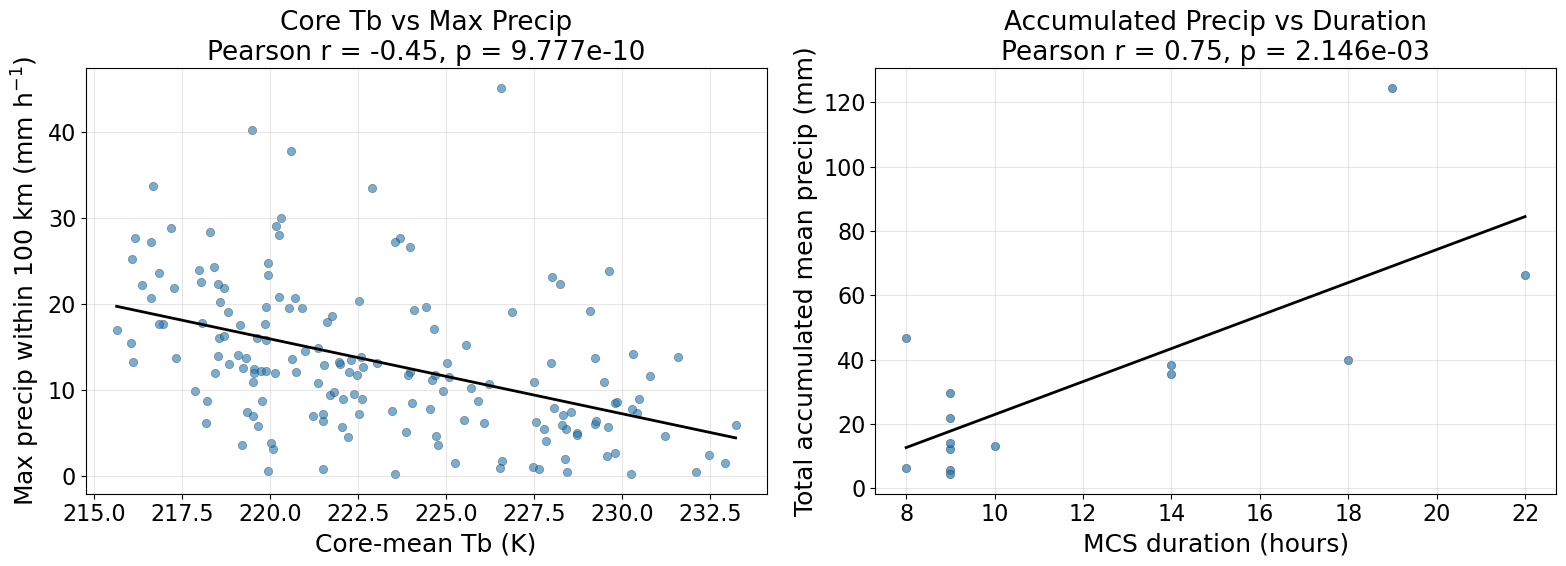

Saved figure to scatter_two_panel.png


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ================= USER SETTINGS =================
CSV_FILE     = "MCS_tracks_with_precip_100km_from_core.csv"
OUT_FIG      = "scatter_two_panel.png"
FONTSIZE     = 18
# =================================================

# ---------- Read data ----------
df = pd.read_csv(CSV_FILE, parse_dates=["datetime_utc", "datetime_hour_rounded"])

plt.rcParams.update({
    "font.size": FONTSIZE,
    "axes.labelsize": FONTSIZE,
    "axes.titlesize": FONTSIZE + 1,
    "xtick.labelsize": FONTSIZE - 2,
    "ytick.labelsize": FONTSIZE - 2,
})

# ==========================================================
# 1) Core Tb vs Max Precip
# ==========================================================
scatter_df1 = df[["meantb_core", "max_precip_100km"]].dropna()

x1 = scatter_df1["meantb_core"].values
y1 = scatter_df1["max_precip_100km"].values

slope1, intercept1, r1, p1, std_err1 = linregress(x1, y1)
y1_fit = slope1 * x1 + intercept1
order1 = np.argsort(x1)

# ==========================================================
# 2) Total accumulated precip vs duration
# ==========================================================
groups = df.groupby("mcs_track_id")

records = []
for track_id, g in groups:
    g = g.sort_values("datetime_utc")
    total_accum = g["accum_mean_precip_100km"].max()
    t0 = g["datetime_utc"].min()
    t1 = g["datetime_utc"].max()
    duration_hours = (t1 - t0).total_seconds() / 3600.0 + 1.0

    records.append({
        "mcs_track_id": track_id,
        "total_accum_precip_mm": total_accum,
        "duration_hours": duration_hours
    })

summary = pd.DataFrame(records).dropna(subset=["total_accum_precip_mm", "duration_hours"])

x2 = summary["duration_hours"].values
y2 = summary["total_accum_precip_mm"].values

slope2, intercept2, r2, p2, std_err2 = linregress(x2, y2)
y2_fit = slope2 * x2 + intercept2
order2 = np.argsort(x2)

# ==========================================================
# 3) Create side-by-side subplots
# ==========================================================
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# ---- Panel 1 ----
ax[0].scatter(x1, y1, alpha=0.6, edgecolor="k", linewidth=0.3)
ax[0].plot(x1[order1], y1_fit[order1], linewidth=2, color="k")
ax[0].set_xlabel("Core-mean Tb (K)")
ax[0].set_ylabel("Max precip within 100 km (mm h$^{-1}$)")
ax[0].set_title(f"Core Tb vs Max Precip\nPearson r = {r1:.2f}, p = {p1:.3e}")
ax[0].grid(True, alpha=0.3)

# ---- Panel 2 ----
ax[1].scatter(x2, y2, alpha=0.7, edgecolor="k", linewidth=0.3)
ax[1].plot(x2[order2], y2_fit[order2], linewidth=2, color="k")
ax[1].set_xlabel("MCS duration (hours)")
ax[1].set_ylabel("Total accumulated mean precip (mm)")
ax[1].set_title(f"Accumulated Precip vs Duration\nPearson r = {r2:.2f}, p = {p2:.3e}")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_FIG, dpi=300)
plt.show()

print(f"Saved figure to {OUT_FIG}")